In [1]:
import yaml
import glob
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd

from sklearn.manifold import TSNE
import matplotlib.cm as cm
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Draw, AllChem
rdBase.DisableLog('rdApp.*')  # RDKitのエラーログを無効化
from rdkit.ML.Cluster import Butina

from tdc import Evaluator as tdc_Evaluator

from mol_data import Mol_Data
from evaluator import Evaluator
from evaluator import population_similarity

diversity_evaluator = tdc_Evaluator(name="Diversity")

In [2]:
class Island:

    def __init__(self, path):
        self.populations = []
        self.offsprings= []
        self.num_generation = 0

        self.load_population(path)
        self.load_offsprings(path)

    def load_population(self,path):
        path = os.path.join(path,'population')
        # 指定されたディレクトリ内で'population_'で始まるすべてのYAMLファイルを検索します。
        yaml_files = glob.glob(os.path.join(path, 'population_*.yaml'))
        if yaml_files == []:
            print("No result files found in {}".format(path))
            return
        self.num_generation = len(yaml_files)

        def get_generation_number(filepath):
            """
            ファイル名から世代番号を抽出するためのヘルパー関数です。
            """
            filename = os.path.basename(filepath)
            # ファイル名の形式は 'population_{世代番号}G.yaml' を想定しています。
            try:
                # 世代番号の文字列を抽出し、整数に変換します。
                gen_str = filename.split('_')[1].replace('G.yaml', '')
                return int(gen_str)
            except (IndexError, ValueError):
                # ファイル名が期待される形式でない場合は-1を返します。
                return -1

        # 世代番号に基づいてYAMLファイルをソートし、時系列順に処理できるようにします。
        yaml_files.sort(key=get_generation_number)

        # ソートされたファイルリストをループ処理し、YAMLデータを読み込んで結果リストに追加します。
        for yaml_file in tqdm(yaml_files):
            with open(yaml_file, 'r', encoding='utf-8') as f:
                datas = yaml.safe_load(f)
                population = []
                for data in datas.values():
                    population.append(Mol_Data(
                        Chem.MolFromSmiles(data["smi"]),
                        data["smi"],
                        data["score"],
                        data["parent1_smi"],
                        data["parent2_smi"]))
                self.populations.append(population)

    def load_offsprings(self, path):
        path = os.path.join(path,'offspring')
        # 指定されたディレクトリ内で'population_'で始まるすべてのYAMLファイルを検索します。
        yaml_files = glob.glob(os.path.join(path, 'offspring_*.yaml'))
        if yaml_files == []:
            print("No result files found in {}".format(path))
            return
        self.num_generation = len(yaml_files)

        def get_generation_number(filepath):
            """
            ファイル名から世代番号を抽出するためのヘルパー関数です。
            """
            filename = os.path.basename(filepath)
            # ファイル名の形式は 'population_{世代番号}G.yaml' を想定しています。
            try:
                # 世代番号の文字列を抽出し、整数に変換します。
                gen_str = filename.split('_')[1].replace('G.yaml', '')
                return int(gen_str)
            except (IndexError, ValueError):
                # ファイル名が期待される形式でない場合は-1を返します。
                return -1

        # 世代番号に基づいてYAMLファイルをソートし、時系列順に処理できるようにします。
        yaml_files.sort(key=get_generation_number)

        # ソートされたファイルリストをループ処理し、YAMLデータを読み込んで結果リストに追加します。
        for yaml_file in yaml_files:
            offspring = []
            with open(yaml_file, 'r', encoding='utf-8') as f:
                datas = yaml.safe_load(f)
                for data in datas.values():
                    offspring.append(Mol_Data(
                        Chem.MolFromSmiles(data["smi"]),
                        data["smi"],
                        data["score"],
                        data["parent1_smi"],
                        data["parent2_smi"]))
            self.offsprings.append(offspring)
                    

In [3]:
class Birth_Info:
    def __init__(self, model, gen):
        self.model = model
        self.gen = gen

class Archipelago:
    def __init__(self, islands):
        self.islands = islands

        self.all_mlcs = {}
        
        print("Loading smi2mlc population ...")
        self.smi2mlc = {}
        self.load_smi2mlc()

        print("Loading all birth ...")
        self.all_birth = {}
        self.load_all_birth()
        
        print("Loading overall ...")
        self.overall_populations = []
        #self.overall()

        print("All loaded.")

    def overall(self, cutoff=0.3, population_size=100):
        min_generation = min([island.num_generation for island in self.islands.values()])
        for gen in range(min_generation):   
            all_population = []
            overall_population = []
            for name, island in self.islands.items():
                all_population.extend(island.populations[gen])
            clusters = self.cluster_population(all_population,cutoff=cutoff)
            for cluster in clusters:
                overall_population.append(max(cluster))

            overall_population.sort(reverse=True)
            overall_population = overall_population[:population_size]
            self.overall_populations.append(overall_population)

    def load_smi2mlc(self):
        for name , island in self.islands.items():
            for mlc in island.populations[0]: 
                if mlc.smi in self.smi2mlc: continue
                self.smi2mlc[mlc.smi] = mlc

        for name , island in self.islands.items():
            for offspring in island.offsprings:
                for mlc in offspring:
                    if mlc.smi in self.smi2mlc: continue
                    self.smi2mlc[mlc.smi] = mlc
        print(f"all mlc : {len(self.smi2mlc)}")

    def load_all_birth(self):
        for name , island in self.islands.items():
            for gen, offspring in enumerate(island.offsprings):
                for mlc in offspring:
                    if mlc.smi in self.all_birth: continue
                    self.all_birth[mlc.smi] = Birth_Info(name,gen)



In [4]:
arc_cluster_1 = Archipelago({
    "Gemma2:9B": Island("results/cluster_jnk3_1/Gemma"),
    "Qwen3:8B": Island("results/cluster_jnk3_1/Qwen3"),
    "BioT5": Island("results/cluster_jnk3_1/BioT5"),
})

arc_cluster_2 = Archipelago({
    "Gemma2:9B": Island("results/cluster_jnk3_2/Gemma"),
    "Qwen3:8B": Island("results/cluster_jnk3_2/Qwen3"),
    "BioT5": Island("results/cluster_jnk3_2/BioT5"),
})

arc_random_1 = Archipelago({
    "Gemma2:9B": Island("results/random_jnk3_1/Gemma"),
    "Qwen3:8B": Island("results/random_jnk3_1/Qwen3"),
    "BioT5": Island("results/random_jnk3_1/BioT5"),
})

arc_random_2 = Archipelago({
    "Gemma2:9B": Island("results/random_jnk3_2/Gemma"),
    "Qwen3:8B": Island("results/random_jnk3_2/Qwen3"),
    "BioT5": Island("results/random_jnk3_2/BioT5"),
})

Long_gemma = [
    Island("results/JNK3/Long_gemma/Gemma1"),
    Island("results/JNK3/Long_gemma/Gemma2"),
    Island("results/JNK3/Long_gemma/Gemma3"),
    Island("results/JNK3/Long_gemma/Gemma4"),
    Island("results/JNK3/Long_gemma/Gemma5"),
]

Long_BioT5 = [
    Island("results/Long_BioT5/BioT5_1"),
    Island("results/Long_BioT5/BioT5_2"),
]

Long_Qwen = [
    Island("results/Long_Qwen/Qwen3_1"),
    Island("results/Long_Qwen/Qwen3_2"),
]


100%|██████████| 100/100 [00:05<00:00, 17.46it/s]


Loading smi2mlc population ...
all mlc : 8906
Loading all birth ...
Loading overall ...
All loaded.


100%|██████████| 100/100 [00:06<00:00, 16.51it/s]


Loading smi2mlc population ...
all mlc : 8841
Loading all birth ...
Loading overall ...
All loaded.


100%|██████████| 100/100 [00:06<00:00, 15.00it/s]


Loading smi2mlc population ...
all mlc : 9415
Loading all birth ...
Loading overall ...
All loaded.


100%|██████████| 100/100 [00:06<00:00, 15.50it/s]


Loading smi2mlc population ...
all mlc : 9569
Loading all birth ...
Loading overall ...
All loaded.


100%|██████████| 100/100 [00:23<00:00,  4.21it/s]


In [ ]:
def gen_all_mlcs_arc(archipelago, gen):
    all_mlcs = {}

    for name, island in archipelago.islands.items():
        for mlc in island.populations[0]:
            if mlc.smi not in all_mlcs:
                all_mlcs[mlc.smi] = mlc

    for name, island in archipelago.islands.items():
        for i in range(0, gen+1):
            for mlc in island.offsprings[i]:
                if mlc.smi not in all_mlcs:
                    all_mlcs[mlc.smi] = mlc
    return all_mlcs

def gen_all_mlcs_mono(island, gen):
    all_mlcs = {}

    for mlc in island.populations[0]:
        if mlc.smi not in all_mlcs:
            all_mlcs[mlc.smi] = mlc

    for i in range(0, gen+1):
        for mlc in island.offsprings[i]:
            if mlc.smi not in all_mlcs:
                all_mlcs[mlc.smi] = mlc
    return all_mlcs

def AUC_score_arc(archipelago, topk = 10, max_orcale_calls = 10000):
    max_gen = min([island.num_generation for island in archipelago.islands.values()])
    sum_score = {name : 0.0 for name in archipelago.islands.keys()}
    old_topk_avg_score = {name : 0.0 for name in archipelago.islands.keys()}
    old_oracle_calls = 0
    for gen in range(0, max_gen):
        new_oracle_calls = len(gen_all_mlcs_arc(archipelago, gen))
        for name, island in archipelago.islands.items():
            topk_avg_score = np.mean(sorted([mlc.score for mlc in island.populations[gen]], reverse=True)[:topk])
            sum_score[name] += (new_oracle_calls - old_oracle_calls) * (topk_avg_score + old_topk_avg_score[name]) / 2
            old_topk_avg_score[name] = topk_avg_score
        old_oracle_calls = new_oracle_calls

    for name, island in archipelago.islands.items():
        sum_score[name] += (max_orcale_calls - old_oracle_calls) * old_topk_avg_score[name]
        
    for name, sum in sum_score.items():
        sum_score[name] = sum / max_orcale_calls

    return sum_score

def AUC_score_mono(island, topk = 10, max_orcale_calls = 10000):
    max_gen = island.num_generation
    sum_score = 0.0
    old_topk_avg_score = 0.0
    old_oracle_calls = 0
    for gen in range(0, max_gen):
        new_oracle_calls = len(gen_all_mlcs_mono(island, gen))
        topk_avg_score = np.mean(sorted([mlc.score for mlc in island.populations[gen]], reverse=True)[:topk])
        sum_score += ( (new_oracle_calls - old_oracle_calls) * (topk_avg_score + old_topk_avg_score) )  / 2
        old_topk_avg_score = topk_avg_score
        old_oracle_calls = new_oracle_calls

    sum_score += (max_orcale_calls - old_oracle_calls) * old_topk_avg_score
    return sum_score / max_orcale_calls

def make_global(populations):
    all_smi = set()
    global_population = []
    for population in populations:
        for mlc in population:
            if mlc.smi not in all_smi:
                global_population.append(mlc)
                all_smi.add(mlc.smi)
    return global_population

def topk_score_arc(archipelago, topk = 10):
    max_gen = min([island.num_generation for island in archipelago.islands.values()])
    topk_avg_scores = {name : [] for name in archipelago.islands.keys()}
    topk_avg_scores["Global"] = []
    for gen in range(0, max_gen):
        for name, island in archipelago.islands.items():
            topk_avg_scores[name].append(np.mean(sorted([mlc.score for mlc in island.populations[gen]], reverse=True)[:topk]))
        global_population = make_global([island.populations[gen] for island in archipelago.islands.values()])
        print(global_population)
        topk_avg_scores["Global"].append(np.mean(sorted([mlc.score for mlc in global_population], reverse=True)[:topk]))
    return topk_avg_scores

def topk_score_mono(island, topk = 10):
    max_gen = island.num_generation
    topk_avg_scores = []
    for gen in range(0, max_gen):
        topk_avg_score = np.mean(sorted([mlc.score for mlc in island.populations[gen]], reverse=True)[:topk])
        topk_avg_scores.append(topk_avg_score)
    return topk_avg_scores

def diversity_arc(archipelago):
    max_gen = min([island.num_generation for island in archipelago.islands.values()])
    div_avg_scores = {name : [] for name in archipelago.islands.keys()}
    div_avg_scores["Global"] = []
    for gen in range(0, max_gen):
        for name, island in archipelago.islands.items():
            div_avg_scores[name].append(population_diversity(island.populations[gen]))
        global_population = make_global([island.populations[gen] for island in archipelago.islands.values()])
        print(len(global_population))
        div_avg_scores["Global"].append(population_diversity(global_population))
    return div_avg_scores

def diversity_mono(island):
    max_gen = island.num_generation
    topk_avg_scores = []
    for gen in range(0, max_gen):
        topk_avg_scores.append(population_diversity(island.populations[gen]))
    return topk_avg_scores

def average_score_arc(archipelagos, score_func):
    # archipelagos: [Archipelago, Archipelago, ...]
    # score_func: function to calculate scores per archipelago
    # Returns: { "Island_name": [avg_scores_per_generation], ... }

    max_gen = min([island.num_generation for island in archipelagos[0].islands.values()])
    arcs_topk_scores = [score_func(arc) for arc in archipelagos]
    island_names = arcs_topk_scores[0].keys()
    arcs_avg_scores = {name : [] for name in island_names}

    for gen in range(max_gen):
        for name in island_names:
            gen_avg_scores = []
            for arc_topk_scores in arcs_topk_scores:
                gen_avg_scores.append(arc_topk_scores[name][gen])
            arcs_avg_scores[name].append(np.mean(gen_avg_scores))

    return arcs_avg_scores

def average_score_mono(islands, score_func):
    # islands: { "Island_name": Island, ... }
    # score_func: function to calculate scores per island
    # Returns: { "Island_name": [avg_scores_per_generation], ... }

    max_gen = min([island.num_generation for island in islands])
    islands_topk_scores = [score_func(island) for island in islands]
    islands_avg_scores = []

    for gen in range(max_gen):
        islands_avg_scores.append(np.mean([score[gen] for score in islands_topk_scores]))
    return islands_avg_scores

def plot_score_shift(avg_scores_dict, xlabel="Generation", ylabel = "Top-10 Average Score", title="Top-10 Average Scores per Generation for Each LLM"):
    # avg_scores_dict = { "name": [avg_scores_per_generation], ... }

    # Plot the avg_scores
    plt.figure(figsize=(10, 6))
    for name, scores in avg_scores_dict.items():
        plt.plot(scores, label=name)

    plt.ylim(0.0,1.0)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

def population_diversity(population):
    smis = [mlc.smi for mlc in population]
    return diversity_evaluator(smis)

def plot_diversity_shift(islands, overall_populations):
    diversities_dict = {name: population_diversity(island.populations) for name, island in islands.items()}
    diversities_dict["Overall"] = population_diversity(overall_populations)
    # Plot the diversities
    plt.figure(figsize=(10, 6))
    for name, diversity_scores in diversities_dict.items():
        plt.plot(diversity_scores, label=name)

    plt.ylim(0.0,1.0)
    plt.xlabel("Generation")
    plt.ylabel("Diversity Score")
    plt.title("Diversity Scores per Generation for Each LLM and Overall")
    plt.legend()
    plt.show()

def cluster_population(population, cutoff=0.2):
    """
    Perform Butina clustering on a population based on molecular fingerprints.

    Args:
        population (list): A list of Mol_Data objects.
        cutoff (float): Tanimoto similarity cutoff for clustering.

    Returns:
        list: A list of clusters, where each cluster is a list of Mol_Data objects.
    """
    # Generate fingerprints for all molecules in the population
    fps = [AllChem.GetMorganFingerprintAsBitVect(mlc.mol, radius=2) for mlc in population]

    # Calculate pairwise Tanimoto similarities
    n = len(fps)
    dists = []
    for i in range(1, n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - sim for sim in sims])  # Convert similarity to distance

    # Perform Butina clustering
    clusters = Butina.ClusterData(dists, nPts=n, distThresh=cutoff, isDistData=True)

    # Map cluster indices to Mol_Data objects
    clustered_population = [[population[idx] for idx in cluster] for cluster in clusters]

    return clustered_population

def draw_molecules(mlcs, num=10):
    # Extract RDKit molecule objects from Mol_Data
    mols = [mlc.mol for mlc in mlcs[:num]]
    
    # Draw the molecules
    img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)

def visualize_multiple_sets(mol_sets_dict, n_components=2, perplexity=30, random_state=42):
    """
    複数の分子集合を受け取り、t-SNEで同一平面上にプロットする関数
    
    Args:
        mol_sets_dict (dict): {"ラベル名": [RDKit Mol objects], ...} の形式
        n_components (int): 圧縮後の次元数（通常2）
        perplexity (int): t-SNEの近傍点パラメータ（データ数に合わせて調整が必要）
        random_state (int): 再現性のための乱数シード
    """
    
    # --- 1. フィンガープリントへの変換と結合 ---
    all_fps = []        # 全てのフィンガープリント（t-SNE学習用）
    dataset_names = []  # プロット時のループ用
    dataset_counts = {} # 各セットのデータ数を記録（後で分割するため）
    
    print("フィンガープリント生成中...")
    
    for name, mols in mol_sets_dict.items():
        fps = []
        for mol in mols:
            if mol is not None:
                try:
                    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
                    arr = np.zeros((1,))
                    DataStructs.ConvertToNumpyArray(fp, arr)
                    fps.append(arr)
                except:
                    pass
        
        if len(fps) > 0:
            np_fps = np.array(fps)
            all_fps.append(np_fps)
            dataset_names.append(name)
            dataset_counts[name] = len(np_fps) # 個数を記録
            print(f"  - {name}: {len(np_fps)} molecules")
        else:
            print(f"  - {name}: 有効な分子がありません (スキップ)")

    if not all_fps:
        print("プロット可能なデータがありません。")
        return

    # 全データを縦に結合 (Stack)
    X_total = np.vstack(all_fps)
    n_samples = X_total.shape[0]

    # --- 2. t-SNEの実行 ---
    # Perplexityの自動調整（データ数が少ない場合の安全策）
    if n_samples <= perplexity:
        perplexity = max(1, n_samples - 1)
        print(f"警告: データ数が少なすぎます。Perplexityを {perplexity} に調整しました。")

    print(f"t-SNE計算中... (Total data shape: {X_total.shape})")
    print("※データ数が多い場合、PCAより時間がかかります...")
    
    # init='pca' にすると初期配置がPCAベースになり、結果が安定しやすくなります
    tsne = TSNE(n_components=n_components, 
                perplexity=perplexity, 
                random_state=random_state,
                init='pca', 
                learning_rate='auto')
    
    X_embedded = tsne.fit_transform(X_total)

    # --- 3. プロット ---
    plt.figure(figsize=(10, 8))
    
    # 色の準備
    colors = cm.get_cmap('tab10', len(dataset_names)) 
    
    current_idx = 0 # データスライスの開始位置
    
    for i, name in enumerate(dataset_names):
        count = dataset_counts[name]
        
        # 結合された結果から、このデータセットに該当する部分を抜き出す
        X_subset = X_embedded[current_idx : current_idx + count]
        current_idx += count # 次の開始位置を更新
        
        # 散布図
        plt.scatter(X_subset[:, 0], X_subset[:, 1], 
                    alpha=0.6,
                    label=name,
                    color=colors(i),
                    s=40,
                    edgecolors='white', linewidth=0.5) 

    # グラフの装飾
    plt.title('Chemical Space Distribution (t-SNE)', fontsize=14)
    plt.xlabel('t-SNE dimension 1', fontsize=12)
    plt.ylabel('t-SNE dimension 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def search_family_tree(archipelago, root_mlc):
    tree = [] # 家系図のSMILESリスト
    
    queue = [] # 探索キュー
    queue.append(root_mlc)

    while(len(queue) > 0):
        mlc = queue.pop(0)
        
        if mlc.smi in tree: continue
        if mlc.parent1_smi == "" or mlc.parent2_smi == "": continue # 初期分子に到達したら終了 初期分子は含めない
        
        tree.append(mlc.smi)

        queue.append(archipelago.smi2mlc[mlc.parent1_smi])
        queue.append(archipelago.smi2mlc[mlc.parent2_smi])

    return tree

def gene_origin_comps(archipelago):
    # 集計データを格納するリスト
    data_list = []

    # トップ分子を格納するリスト
    top_mols = []
    top_mols_legends = []

    # 集計対象のモデル名
    target_models = archipelago.islands.keys()
    for name, island in archipelago.islands.items():
        # 元のコードのロジック（search_family_treeのタイポはそのまま維持しています）
        top_mlc = max(archipelago.islands[name].populations[-1])
        tree = search_family_tree(archipelago, top_mlc)

        # トップ分子をリストに追加
        top_mols.append(top_mlc.mol)
        top_mols_legends.append(f"{name}\nScore: {top_mlc.score:.3f}")

        model_count = [archipelago.all_birth[smi].model for smi in tree]
        
        # 各モデルのカウントを取得して辞書に格納
        counts = {"Island": name}
        for model in target_models:
            counts[model] = model_count.count(model)
        print(counts)
        data_list.append(counts)

    # 分子の描画
    print("Top 1 Molecules per Island:")
    if top_mols:
        img = Draw.MolsToGridImage(top_mols, legends=top_mols_legends, molsPerRow=min(len(top_mols), 5), subImgSize=(200, 200))
        display(img)

    # DataFrameに変換
    df = pd.DataFrame(data_list)
    df.set_index("Island", inplace=True)

    # 100%積み上げにするために、各行をその行の合計値で割って正規化する
    # (合計が0の場合はNaNになる可能性があるため、fillna(0)で処理しても良いですが、通常データがあれば不要です)
    df_normalized = df.div(df.sum(axis=1), axis=0)

    # プロット設定
    fig, ax = plt.subplots(figsize=(12, 6))

    # 積み上げ棒グラフの描画 (stacked=True)
    df_normalized.plot(kind='bar', stacked=True, ax=ax, width=0.8, alpha=0.8)

    # グラフの装飾
    ax.set_title("Composition of Genetic Origins in Top-1 Molecules across Island Populations", fontsize=14)
    ax.set_xlabel("Island Name", fontsize=12)
    ax.set_ylabel("Percentage", fontsize=12)

    # Y軸をパーセント表示にするフォーマット
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.0%}".format(x)))

    # 凡例をグラフの外側に配置
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

def population_similarity_matrix(model_islands):
    # model_islands (dict): {"model名": [island1, island2, ...], ...}

    model_names = list(model_islands.keys())
    num_models = len(model_names)
    similarity_matrix = np.zeros((num_models, num_models))

    for i in range(num_models):
        for j in range(num_models):
            
            # --- Case 1: 同じモデル同士 (対角成分) ---
            if i == j:
                islands = model_islands[model_names[i]]
                n_islands = len(islands)
                if n_islands < 2:
                    similarity_matrix[i, j] = 1.0 # 比較対象がない場合
                    continue
                
                sum_similarity = 0.0
                pair_count = 0
                # 全ペアの平均 (Average pairwise similarity)
                for k in range(n_islands):
                    for l in range(k + 1, n_islands):
                        # ※ population_similarity関数が (0~1) を返すと仮定
                        similarity = population_similarity(islands[k].populations[-1], islands[l].populations[-1])
                        sum_similarity += similarity
                        pair_count += 1
                
                similarity_matrix[i, j] = sum_similarity / pair_count

            # --- Case 2: 異なるモデル間 (非対角成分) ---
            # i < j の時だけ計算するのではなく、両方向を考慮して埋める
            elif i < j:
                islands_i = model_islands[model_names[i]]
                islands_j = model_islands[model_names[j]]

                # 方向1: i -> j (iの各島について、最も似ているjの島を探す)
                max_sims_i_to_j = []
                for k in range(len(islands_i)):
                    sims = []
                    for l in range(len(islands_j)):
                        s = population_similarity(islands_i[k].populations[-1], islands_j[l].populations[-1])
                        sims.append(s)
                    max_sims_i_to_j.append(max(sims)) # Max Similarity
                score_i_to_j = np.mean(max_sims_i_to_j) # Average of Max

                # 方向2: j -> i (jの各島について、最も似ているiの島を探す)
                max_sims_j_to_i = []
                for l in range(len(islands_j)):
                    sims = []
                    for k in range(len(islands_i)):
                        # 計算済みであれば再利用も可能だが、コードの単純化のため再計算
                        s = population_similarity(islands_j[l].populations[-1], islands_i[k].populations[-1])
                        sims.append(s)
                    max_sims_j_to_i.append(max(sims)) # Max Similarity
                score_j_to_i = np.mean(max_sims_j_to_i) # Average of Max

                # 最終スコア: 双方向の平均をとる
                final_score = (score_i_to_j + score_j_to_i) / 2.0
                
                similarity_matrix[i, j] = final_score
                similarity_matrix[j, i] = final_score # 対称行列にする

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_matrix, xticklabels=model_names, yticklabels=model_names, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Pairwise Similarity of Generated Molecules: Intra-model vs. Inter-model")
    plt.show()


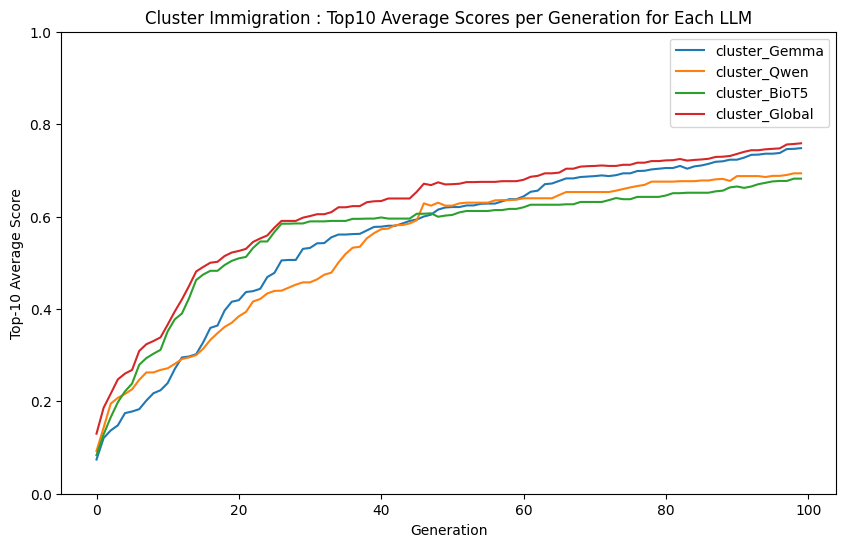

In [23]:
cluster_score = average_score_arc([arc_cluster_1, arc_cluster_2], topk_score_arc)
plot_score_shift({
    "cluster_Gemma": cluster_score["Gemma2:9B"],
    "cluster_Qwen": cluster_score["Qwen3:8B"],
    "cluster_BioT5": cluster_score["BioT5"],
    "cluster_Global": cluster_score["Global"],
},title="Cluster Immigration : Top10 Average Scores per Generation for Each LLM")

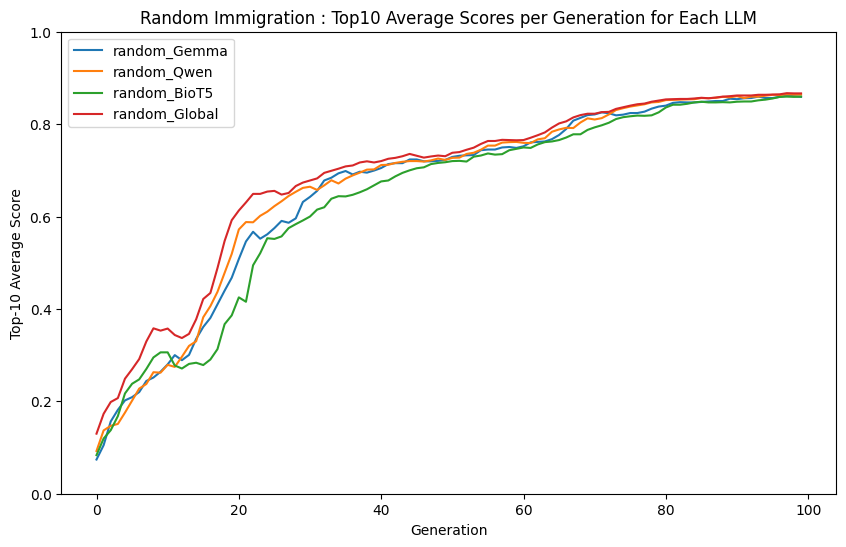

In [24]:
random_score = average_score_arc([arc_random_1, arc_random_2], topk_score_arc)
plot_score_shift({
    "random_Gemma": random_score["Gemma2:9B"],
    "random_Qwen": random_score["Qwen3:8B"],
    "random_BioT5 ": random_score["BioT5"],
    "random_Global ": random_score["Global"],
},title="Random Immigration : Top10 Average Scores per Generation for Each LLM")

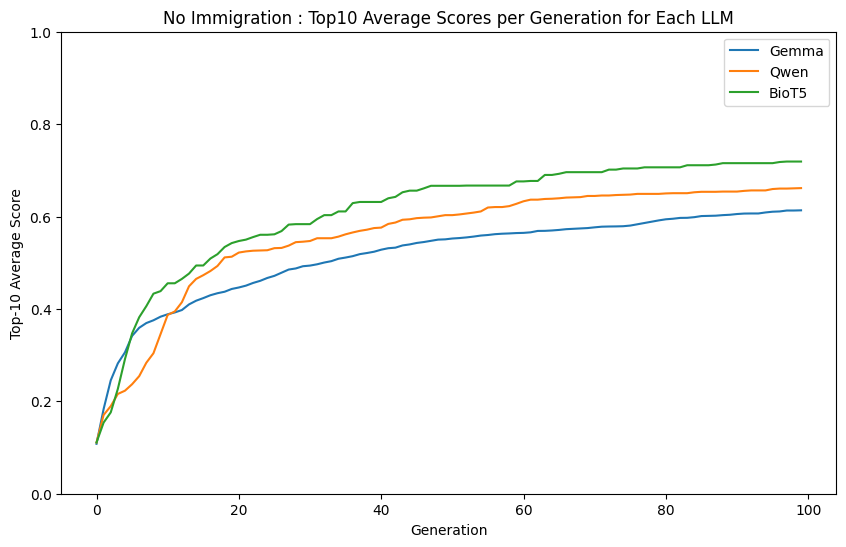

In [25]:
plot_score_shift({
    "Gemma": average_score_mono(Long_gemma,topk_score_mono),
    "Qwen": average_score_mono(Long_Qwen,topk_score_mono),
    "BioT5": average_score_mono(Long_BioT5,topk_score_mono),
},title="No Immigration : Top10 Average Scores per Generation for Each LLM")

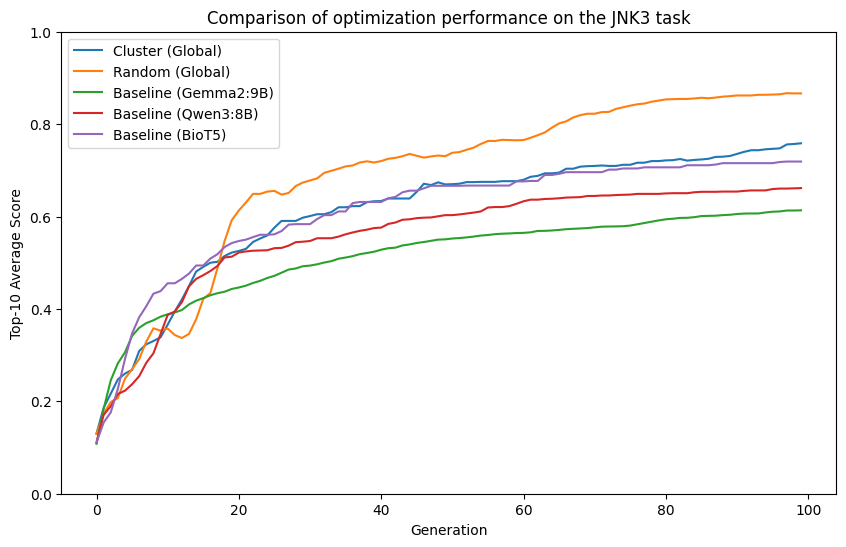

In [26]:
plot_score_shift({
    "Cluster (Global)": cluster_score["Global"],
    "Random (Global)": random_score["Global"],
    "Baseline (Gemma2:9B)": average_score_mono(Long_gemma,topk_score_mono),
    "Baseline (Qwen3:8B)": average_score_mono(Long_Qwen,topk_score_mono),
    "Baseline (BioT5)": average_score_mono(Long_BioT5,topk_score_mono),
},title="Comparison of optimization performance on the JNK3 task")

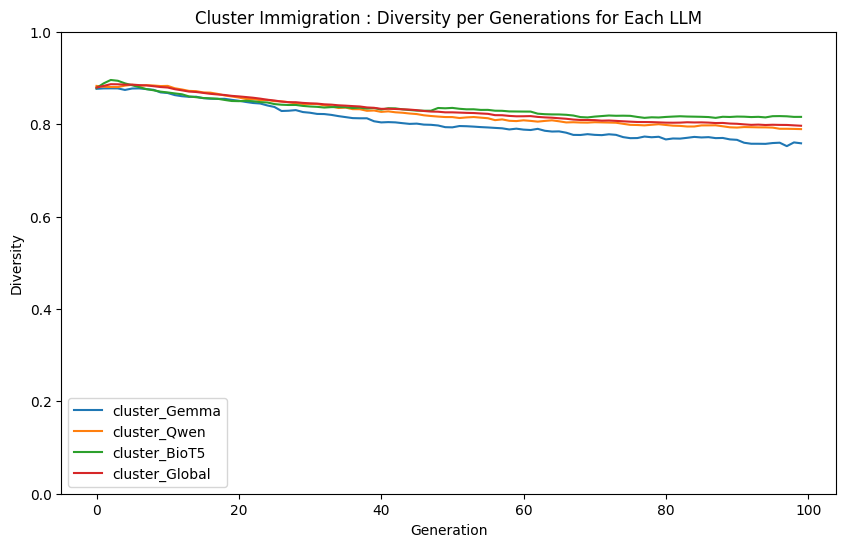

In [27]:
cluster_div = average_score_arc([arc_cluster_1, arc_cluster_2], diversity_arc)
plot_score_shift({
    "cluster_Gemma": cluster_div["Gemma2:9B"],
    "cluster_Qwen": cluster_div["Qwen3:8B"],
    "cluster_BioT5": cluster_div["BioT5"],
    "cluster_Global": cluster_div["Global"],
},ylabel="Diversity", title="Cluster Immigration : Diversity per Generations for Each LLM")

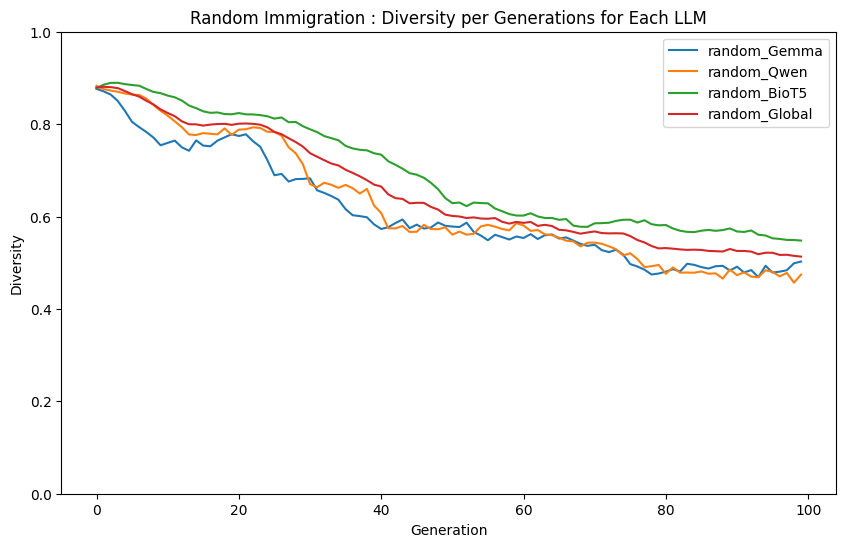

In [28]:
random_div = average_score_arc([arc_random_1, arc_random_2], diversity_arc)
plot_score_shift({
    "random_Gemma": random_div["Gemma2:9B"],
    "random_Qwen": random_div["Qwen3:8B"],
    "random_BioT5": random_div["BioT5"],
    "random_Global": random_div["Global"],
},ylabel="Diversity", title="Random Immigration : Diversity per Generations for Each LLM")

In [29]:
for gemma in Long_gemma:
    print(population_diversity(gemma.populations[-1]))

0.3869943849233412
0.4796375574648566
0.4802329280938295
0.47419406426898303
0.3203655203456003


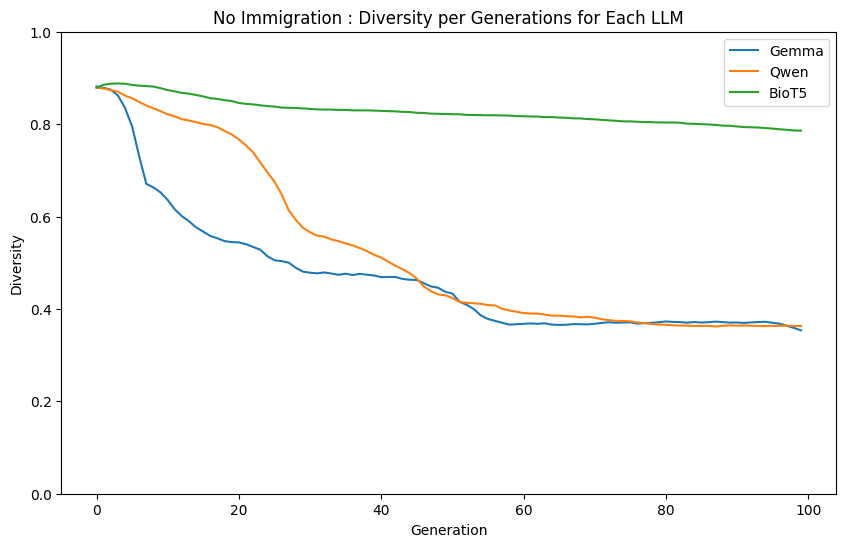

In [30]:
plot_score_shift({
    "Gemma": average_score_mono([Long_gemma[0],Long_gemma[4]],diversity_mono),
    "Qwen": average_score_mono(Long_Qwen,diversity_mono),
    "BioT5": average_score_mono(Long_BioT5,diversity_mono),
},ylabel="Diversity", title="No Immigration : Diversity per Generations for Each LLM")

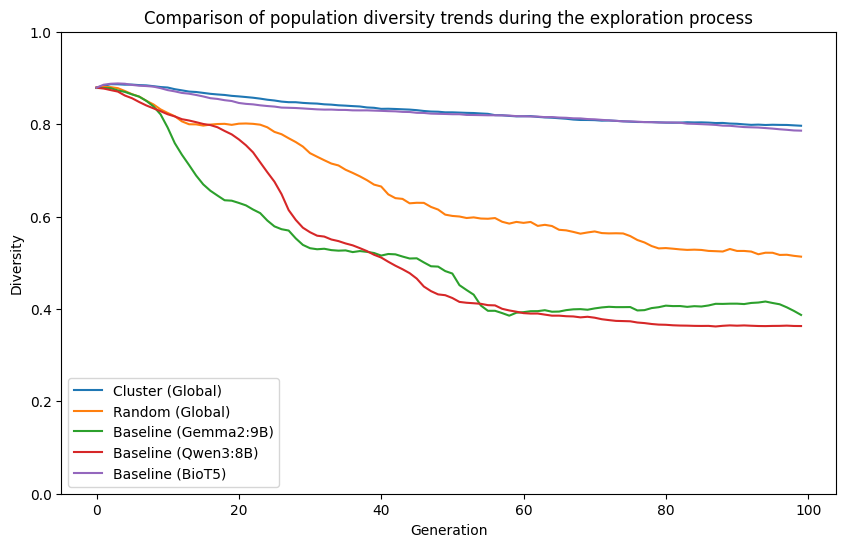

In [31]:
plot_score_shift({
    "Cluster (Global)": cluster_div["Global"],
    "Random (Global)": random_div["Global"],
    "Baseline (Gemma2:9B)": average_score_mono([Long_gemma[0]],diversity_mono),
    "Baseline (Qwen3:8B)": average_score_mono(Long_Qwen,diversity_mono),
    "Baseline (BioT5)": average_score_mono(Long_BioT5,diversity_mono),
},ylabel="Diversity", title="Comparison of population diversity trends during the exploration process")